In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



In [12]:
path = r'C:\Users\samik\Downloads\weatherAUS (3).zip'
data = pd.read_csv(path)
data

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [13]:
data = data.drop(columns=['Date', 'Location', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow'])
column_mean = data['Rainfall'].replace(0, pd.NA).mean()
data['Rainfall'] = data['Rainfall'].replace(0, column_mean)
data = data.fillna(data.mean())
data

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
0,13.4,22.900000,0.600000,44.00000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.50993,16.9,21.8
1,7.4,25.100000,6.567425,44.00000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.447461,4.50993,17.2,24.3
2,12.9,25.700000,6.567425,46.00000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.447461,2.00000,21.0,23.2
3,9.2,28.000000,6.567425,24.00000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.447461,4.50993,18.1,26.5
4,17.5,32.300000,1.000000,41.00000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.00000,17.8,29.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2.8,23.400000,6.567425,31.00000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.447461,4.50993,10.1,22.4
145456,3.6,25.300000,6.567425,22.00000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.447461,4.50993,10.9,24.5
145457,5.4,26.900000,6.567425,37.00000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.447461,4.50993,12.5,26.1
145458,7.8,27.000000,6.567425,28.00000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.00000,15.1,26.0


In [14]:
features = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am', 'Humidity3pm', 'Temp9am', 'Temp3pm', 'Cloud9am', 'Cloud3pm', 'WindGustSpeed']


In [15]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[features])
scaled_features

array([[ 1.89446615e-01, -4.53363105e-02, -7.66839815e-01, ...,
         1.56803670e+00, -8.48734694e-16,  3.02234118e-01],
       [-7.53100728e-01,  2.65043084e-01,  4.69093830e-14, ...,
        -3.92028479e-16, -8.48734694e-16,  3.02234118e-01],
       [ 1.10901003e-01,  3.49692009e-01,  4.69093830e-14, ...,
        -3.92028479e-16, -1.19923244e+00,  4.54693970e-01],
       ...,
       [-1.06728318e+00,  5.18989861e-01,  4.69093830e-14, ...,
        -3.92028479e-16, -8.48734694e-16, -2.31375364e-01],
       [-6.90264238e-01,  5.33098015e-01,  4.69093830e-14, ...,
        -6.38887439e-01, -1.19923244e+00, -9.17444698e-01],
       [ 4.25083451e-01, -5.01222327e-16,  4.69093830e-14, ...,
         1.56803670e+00,  1.66753850e+00,  0.00000000e+00]])

In [16]:
sse = []
k_rng = range(1, 10)
for k in k_rng:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_features)
    sse.append(km.inertia_)
sse

[1454600.000000004,
 1059864.532088492,
 930417.8737502665,
 833543.5442733285,
 782623.9095254516,
 739277.6670298588,
 706033.9146717518,
 639789.9551183847,
 617077.1429440575]

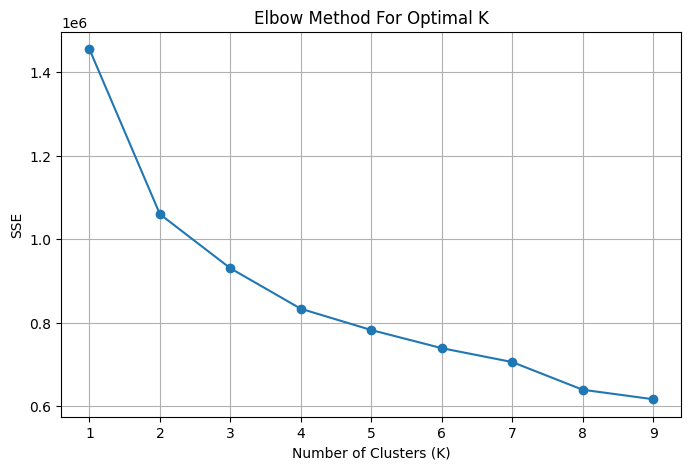

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(k_rng, sse, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE')
plt.title('Elbow Method For Optimal K')
plt.grid(True)
plt.show()


In [18]:
optimal_k = 2  
km = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = km.fit_predict(scaled_features)

In [19]:
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(scaled_features)
reduced_features

array([[ 0.16928633,  0.15499567],
       [ 0.88703275, -1.03676393],
       [ 1.66260255, -1.03086551],
       ...,
       [ 0.51893245, -1.30466461],
       [ 1.13260702, -2.02884786],
       [-0.25687769,  1.224929  ]])

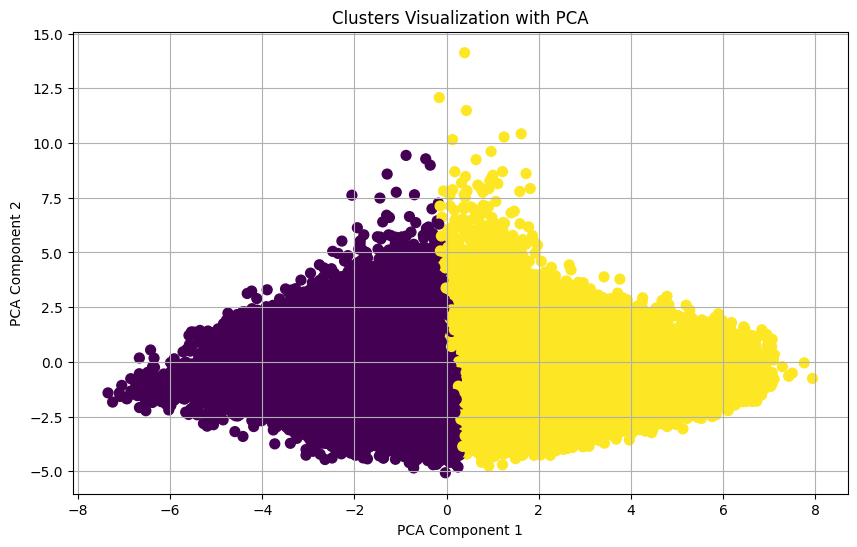

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=data['Cluster'], cmap='viridis', s=50)
#plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title('Clusters Visualization with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()

In [22]:
print(data['Cluster'].value_counts())

Cluster
0    79497
1    65963
Name: count, dtype: int64
